# IT3051 Fundamentals of Data Mining — Algorithm 3: Fuzzy C-Means (FCM)

## Project: Soft E-commerce Customer Segmentation and Retention Prioritization

### Purpose and Overview
This notebook implements **Fuzzy C-Means (FCM)** clustering for soft/fuzzy customer segmentation.
FCM assigns each customer continuous membership grades across all clusters, allowing direct measurement of boundary ambiguity and multi-segment affinity.

### Critical Group Constraints
- **DO NOT independently re-split the original dataset.**
- **DO NOT re-scale or modify features independently.**
- All models must consume the shared preprocessed data produced by `01_EDA_Preprocessing.ipynb`:
  - `data/processed/development_preprocessed.csv` (40,000 customers, 18 features + `customer_id`)
  - `data/processed/holdout_preprocessed.csv` (10,000 customers, 18 features + `customer_id`)
- `customer_id` is for alignment only and **MUST NOT** be passed to the clustering algorithm:
  ```python
  X_dev = development_preprocessed.drop(columns=["customer_id"])
  ```
- Business variables (`customer_lifetime_value_usd`, `churn_risk_score`) are deliberately kept outside clustering and stored in `development_business_data.csv`.

---
*Note: Placeholder notebook. Model tuning and evaluation will be executed in the next project phase.*


# Fuzzy C-Means Customer Segmentation

## Objective

This notebook develops and evaluates a Fuzzy C-Means (FCM) clustering model for soft e-commerce customer segmentation.

Unlike hard clustering methods such as K-Means, Fuzzy C-Means allows each customer to belong to multiple clusters with different membership degrees.

The model is developed using the frozen development dataset created during the preprocessing stage. The holdout dataset is kept separate until the final FCM configuration has been selected.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Find project root
cwd = Path.cwd()

if (cwd / "data" / "processed").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "processed").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate the project root.")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\ASUS\Pictures\final fdm


In [2]:
development_df = pd.read_csv(
    DATA_DIR / "development_preprocessed.csv"
)

holdout_df = pd.read_csv(
    DATA_DIR / "holdout_preprocessed.csv"
)

print("Development shape:", development_df.shape)
print("Holdout shape:", holdout_df.shape)

display(development_df.head())

Development shape: (40000, 19)
Holdout shape: (10000, 19)


,customer_id,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,shopping_channel_In-Store,shopping_channel_Marketplace,shopping_channel_Mobile App,shopping_channel_Online,device_used_Desktop,device_used_Mobile,device_used_Multiple,device_used_Tablet
0,CUST-000001,0.505593,-1.236640,1.427907,0.003000,0.947374,1.388104,1.403874,-1.664856,-1.278390,-1.479339,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,CUST-000002,0.593109,-0.423744,-0.715218,3.003013,-1.471016,1.619288,1.403874,-1.436944,-1.153520,1.640290,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,CUST-000003,0.768140,1.098276,0.556664,0.013752,-1.471016,-0.692552,-0.007853,-0.763568,1.225955,0.822970,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,CUST-000004,-0.982169,1.599850,0.380412,-0.652917,0.256405,0.232184,1.403874,1.377424,0.213118,-0.097953,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,CUST-000006,1.001514,0.198901,-0.285570,-0.652917,1.120116,-0.461368,1.403874,-1.177953,-0.716473,1.306455,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [3]:
development_ids = development_df["customer_id"].copy()
holdout_ids = holdout_df["customer_id"].copy()

X_dev = development_df.drop(columns=["customer_id"]).copy()
X_holdout = holdout_df.drop(columns=["customer_id"]).copy()

print("X_dev:", X_dev.shape)
print("X_holdout:", X_holdout.shape)

X_dev: (40000, 18)
X_holdout: (10000, 18)


Final safety checks

In [4]:
print("Missing values in development:", X_dev.isna().sum().sum())
print("Missing values in holdout:", X_holdout.isna().sum().sum())

print(
    "Development finite:",
    np.isfinite(X_dev.to_numpy()).all()
)

print(
    "Holdout finite:",
    np.isfinite(X_holdout.to_numpy()).all()
)

print("\nFeatures:")
for i, feature in enumerate(X_dev.columns, start=1):
    print(f"{i:02d}. {feature}")

Missing values in development: 0
Missing values in holdout: 0
Development finite: True
Holdout finite: True

Features:
01. tenure_months
02. total_purchases
03. avg_order_value_usd
04. days_since_last_purchase
05. return_count
06. complaint_count
07. satisfaction_score
08. email_open_rate
09. click_through_rate
10. conversion_rate
11. shopping_channel_In-Store
12. shopping_channel_Marketplace
13. shopping_channel_Mobile App
14. shopping_channel_Online
15. device_used_Desktop
16. device_used_Mobile
17. device_used_Multiple
18. device_used_Tablet


## Baseline Fuzzy C-Means Model

A baseline Fuzzy C-Means model is first trained to verify that the
algorithm operates correctly on the preprocessed development dataset.

The initial configuration uses:

- Number of clusters (K): 3
- Fuzziness parameter (m): 2.0
- Convergence error: 0.005
- Maximum iterations: 1000
- Random seed: 42

This configuration is only a baseline and does not represent the final
selected model. The number of clusters and fuzziness parameter will be
systematically evaluated later.

In [16]:
# FCM expects features × samples rather than samples × features
X_dev_fcm = X_dev.to_numpy().T

print("Original X_dev shape:", X_dev.shape)
print("FCM input shape:", X_dev_fcm.shape)

Original X_dev shape: (40000, 18)
FCM input shape: (18, 40000)


Train the baseline

In [17]:
baseline_k = 3
baseline_m = 2.0

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_dev_fcm,
    c=baseline_k,
    m=baseline_m,
    error=0.005,
    maxiter=1000,
    init=None,
    seed=42
)

print("Cluster centers shape:", cntr.shape)
print("Membership matrix shape:", u.shape)
print("Iterations:", p)
print("FPC:", round(fpc, 4))

Cluster centers shape: (3, 18)
Membership matrix shape: (3, 40000)
Iterations: 6
FPC: 0.3333


Verify the fuzzy memberships

In [18]:
print("Memberships of first customer:")
for cluster_idx in range(baseline_k):
    print(
        f"Cluster {cluster_idx + 1}: "
        f"{u[cluster_idx, 0]:.4f}"
    )

print(
    "\nMembership sum:",
    round(u[:, 0].sum(), 6)
)

Memberships of first customer:
Cluster 1: 0.3333
Cluster 2: 0.3333
Cluster 3: 0.3333

Membership sum: 1.0


In [19]:
baseline_labels = np.argmax(u, axis=0)

unique, counts = np.unique(
    baseline_labels,
    return_counts=True
)

cluster_sizes = pd.DataFrame({
    "cluster": unique + 1,
    "customers": counts
})

display(cluster_sizes)

,cluster,customers
0,1,11133
1,2,15938
2,3,12929


check the whole membership matrix

In [20]:
# Maximum membership for each customer
max_memberships = np.max(u, axis=0)

print("Maximum membership statistics:")
print(pd.Series(max_memberships).describe())

# How many customers have weak/strong memberships?
print("\nCustomers with max membership < 0.40:",
      np.sum(max_memberships < 0.40))

print("Customers with max membership >= 0.50:",
      np.sum(max_memberships >= 0.50))

print("Customers with max membership >= 0.70:",
      np.sum(max_memberships >= 0.70))

print("Customers with max membership >= 0.90:",
      np.sum(max_memberships >= 0.90))

Maximum membership statistics:
count    40000.000000
mean         0.333339
std          0.000004
min          0.333333
25%          0.333337
50%          0.333339
75%          0.333341
max          0.333358
dtype: float64

Customers with max membership < 0.40: 40000
Customers with max membership >= 0.50: 0
Customers with max membership >= 0.70: 0
Customers with max membership >= 0.90: 0


check whether the centers have actually separated

In [21]:
from scipy.spatial.distance import pdist, squareform

center_distances = squareform(
    pdist(cntr, metric="euclidean")
)

center_distance_df = pd.DataFrame(
    center_distances,
    index=[f"Cluster {i+1}" for i in range(baseline_k)],
    columns=[f"Cluster {i+1}" for i in range(baseline_k)]
)

display(center_distance_df)

,Cluster 1,Cluster 2,Cluster 3
Cluster 1,0.000000,0.000179,0.000113
Cluster 2,0.000179,0.000000,0.000197
Cluster 3,0.000113,0.000197,0.000000


In [22]:
membership_preview = pd.DataFrame(
    u[:, :10].T,
    columns=[
        f"Cluster_{i+1}_membership"
        for i in range(baseline_k)
    ]
)

membership_preview["max_membership"] = (
    membership_preview.max(axis=1)
)

display(membership_preview)

,Cluster_1_membership,Cluster_2_membership,Cluster_3_membership,max_membership
0,0.333326,0.333344,0.333331,0.333344
1,0.333334,0.333339,0.333327,0.333339
2,0.333340,0.333329,0.333331,0.333340
3,0.333335,0.333332,0.333333,0.333335
4,0.333329,0.333350,0.333322,0.333350
5,0.333331,0.333333,0.333336,0.333336
6,0.333335,0.333324,0.333341,0.333341
7,0.333330,0.333336,0.333334,0.333336
8,0.333334,0.333337,0.333328,0.333337
9,0.333329,0.333344,0.333326,0.333344


test whether m is causing excessive fuzziness

In [23]:
diagnostic_results = []

for m_value in [1.2, 1.3, 1.5, 1.8, 2.0]:

    cntr_test, u_test, _, _, _, iterations, fpc_test = fuzz.cluster.cmeans(
        X_dev_fcm,
        c=3,
        m=m_value,
        error=0.005,
        maxiter=1000,
        init=None,
        seed=42
    )

    max_u = np.max(u_test, axis=0)

    center_dists = pdist(cntr_test, metric="euclidean")

    diagnostic_results.append({
        "m": m_value,
        "FPC": fpc_test,
        "mean_max_membership": max_u.mean(),
        "min_max_membership": max_u.min(),
        "max_max_membership": max_u.max(),
        "mean_center_distance": center_dists.mean(),
        "min_center_distance": center_dists.min(),
        "iterations": iterations
    })

diagnostic_df = pd.DataFrame(diagnostic_results)

display(diagnostic_df)

,m,FPC,mean_max_membership,min_max_membership,max_max_membership,mean_center_distance,min_center_distance,iterations
0,1.2,0.378513,0.471861,0.334078,0.821937,0.725362,0.711288,408
1,1.3,0.333333,0.333377,0.333333,0.333523,0.000356,0.000222,16
2,1.5,0.333333,0.333344,0.333333,0.333377,0.000141,0.000093,9
3,1.8,0.333333,0.333338,0.333333,0.333353,0.000106,0.000072,7
4,2.0,0.333333,0.333339,0.333333,0.333358,0.000163,0.000113,6


refine the fuzziness search

In [25]:
refined_m_values = [
    1.05, 1.10, 1.15, 1.20, 1.25, 1.30
]

refined_results = []

for m_value in refined_m_values:

    cntr_test, u_test, _, _, _, iterations, fpc_test = (
        fuzz.cluster.cmeans(
            X_dev_fcm,
            c=3,
            m=m_value,
            error=0.005,
            maxiter=1000,
            init=None,
            seed=42
        )
    )

    max_u = np.max(u_test, axis=0)
    center_dists = pdist(cntr_test, metric="euclidean")

    refined_results.append({
        "m": m_value,
        "FPC": fpc_test,
        "mean_max_membership": max_u.mean(),
        "median_max_membership": np.median(max_u),
        "max_max_membership": max_u.max(),
        "mean_center_distance": center_dists.mean(),
        "min_center_distance": center_dists.min(),
        "iterations": iterations
    })

refined_m_df = pd.DataFrame(refined_results)

display(refined_m_df)

,m,FPC,mean_max_membership,median_max_membership,max_max_membership,mean_center_distance,min_center_distance,iterations
0,1.05,0.898505,0.922260,0.995785,1.000000,2.339794,1.717321,59
1,1.10,0.701018,0.789743,0.826533,0.999949,1.700696,1.676146,257
2,1.15,0.529161,0.649886,0.645104,0.991615,1.360506,1.342532,479
3,1.20,0.378513,0.471861,0.457689,0.821937,0.725362,0.711288,408
4,1.25,0.333333,0.333444,0.333432,0.333824,0.000749,0.000445,27
5,1.30,0.333333,0.333377,0.333372,0.333523,0.000356,0.000222,16


### Baseline Fuzziness Diagnostic

The initial FCM model with K=3 and m=2.0 produced almost uniform
membership values of approximately 0.3333 and nearly coincident cluster
centers. This indicated cluster-center collapse rather than meaningful
soft segmentation.

A diagnostic experiment was therefore performed using multiple
fuzziness values. At m=1.2, the cluster centers became substantially
more separated and customer membership values became more
differentiated. In contrast, m values of 1.3 and above produced
near-uniform memberships in this experiment.

These findings indicate that the dataset is sensitive to the fuzziness
parameter. Therefore, a refined search around lower m values is required
before selecting an FCM configuration. No final m value is selected at
this stage.

In [26]:
# Fixed sample indices for computationally efficient silhouette evaluation
rng = np.random.default_rng(42)

silhouette_sample_size = min(10000, len(X_dev))

silhouette_idx = rng.choice(
    len(X_dev),
    size=silhouette_sample_size,
    replace=False
)

print("Silhouette evaluation sample size:", silhouette_sample_size)

Silhouette evaluation sample size: 10000


In [27]:
import time

k_values = range(2, 9)
m_values = [1.05, 1.10, 1.15, 1.20]

fcm_results = []

X_dev_array = X_dev.to_numpy()

for k in k_values:
    for m_value in m_values:

        print(f"Running K={k}, m={m_value}...")

        start_time = time.perf_counter()

        cntr_test, u_test, _, _, jm_test, iterations, fpc_test = (
            fuzz.cluster.cmeans(
                X_dev_fcm,
                c=k,
                m=m_value,
                error=0.005,
                maxiter=1000,
                init=None,
                seed=42
            )
        )

        runtime = time.perf_counter() - start_time

        # Hard labels only for common evaluation metrics
        labels_test = np.argmax(u_test, axis=0)

        n_clusters_found = len(np.unique(labels_test))

        # Membership diagnostics
        max_membership = np.max(u_test, axis=0)

        # Center separation
        center_dists = pdist(cntr_test, metric="euclidean")

        # Common clustering metrics require at least 2 clusters
        if n_clusters_found >= 2:

            silhouette = silhouette_score(
                X_dev_array[silhouette_idx],
                labels_test[silhouette_idx]
            )

            db = davies_bouldin_score(
                X_dev_array,
                labels_test
            )

            ch = calinski_harabasz_score(
                X_dev_array,
                labels_test
            )

        else:
            silhouette = np.nan
            db = np.nan
            ch = np.nan

        cluster_counts = np.bincount(
            labels_test,
            minlength=k
        )

        fcm_results.append({
            "K": k,
            "m": m_value,
            "FPC": fpc_test,
            "silhouette": silhouette,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
            "mean_max_membership": max_membership.mean(),
            "median_max_membership": np.median(max_membership),
            "mean_center_distance": center_dists.mean(),
            "min_center_distance": center_dists.min(),
            "iterations": iterations,
            "runtime_seconds": runtime,
            "smallest_cluster": cluster_counts.min(),
            "largest_cluster": cluster_counts.max(),
            "clusters_found": n_clusters_found
        })

fcm_results_df = pd.DataFrame(fcm_results)

display(fcm_results_df)

Running K=2, m=1.05...
Running K=2, m=1.1...
Running K=2, m=1.15...
Running K=2, m=1.2...
Running K=3, m=1.05...
Running K=3, m=1.1...
Running K=3, m=1.15...
Running K=3, m=1.2...
Running K=4, m=1.05...
Running K=4, m=1.1...
Running K=4, m=1.15...
Running K=4, m=1.2...
Running K=5, m=1.05...
Running K=5, m=1.1...
Running K=5, m=1.15...
Running K=5, m=1.2...
Running K=6, m=1.05...
Running K=6, m=1.1...
Running K=6, m=1.15...
Running K=6, m=1.2...
Running K=7, m=1.05...
Running K=7, m=1.1...
Running K=7, m=1.15...
Running K=7, m=1.2...
Running K=8, m=1.05...
Running K=8, m=1.1...
Running K=8, m=1.15...
Running K=8, m=1.2...


,K,m,FPC,silhouette,davies_bouldin,calinski_harabasz,mean_max_membership,median_max_membership,mean_center_distance,min_center_distance,iterations,runtime_seconds,smallest_cluster,largest_cluster,clusters_found
0,2,1.05,0.900721,0.064964,3.745992,2789.384473,0.931630,0.992363,1.685729,1.685729,51,0.665122,19999,20001,2
1,2,1.10,0.780628,0.064900,3.746448,2788.670990,0.847971,0.900976,1.513370,1.513370,73,1.226565,19993,20007,2
2,2,1.15,0.648743,0.064445,3.752852,2779.001450,0.743877,0.760174,1.177630,1.177630,159,1.822171,19982,20018,2
3,2,1.20,0.531757,0.058392,3.960760,2492.615389,0.603648,0.592572,0.584318,0.584318,1000,12.243968,19994,20006,2
4,3,1.05,0.898505,0.073911,3.174785,2910.080546,0.922260,0.995785,2.339794,1.717321,59,0.856504,6034,17035,3
5,3,1.10,0.701018,0.054740,3.373019,2369.795200,0.789743,0.826533,1.700696,1.676146,257,3.728853,12498,14347,3
6,3,1.15,0.529161,0.054306,3.362326,2352.580721,0.649886,0.645104,1.360506,1.342532,479,6.893715,12617,14157,3
7,3,1.20,0.378513,0.050988,3.469972,2179.030502,0.471861,0.457689,0.725362,0.711288,408,5.797190,13278,13370,3
8,4,1.05,0.879886,0.062970,2.980423,2574.832787,0.916462,0.988701,2.336171,1.847440,192,3.903450,5734,12659,4
9,4,1.10,0.734695,0.062982,2.974649,2572.753696,0.814752,0.866602,2.238439,1.734569,330,6.736063,5740,12289,4


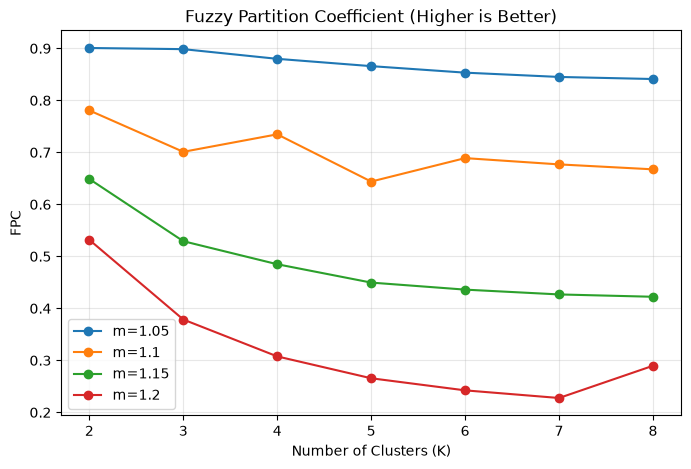

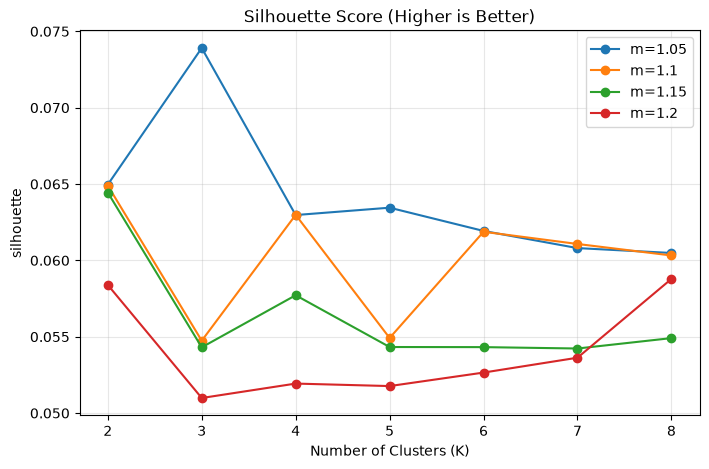

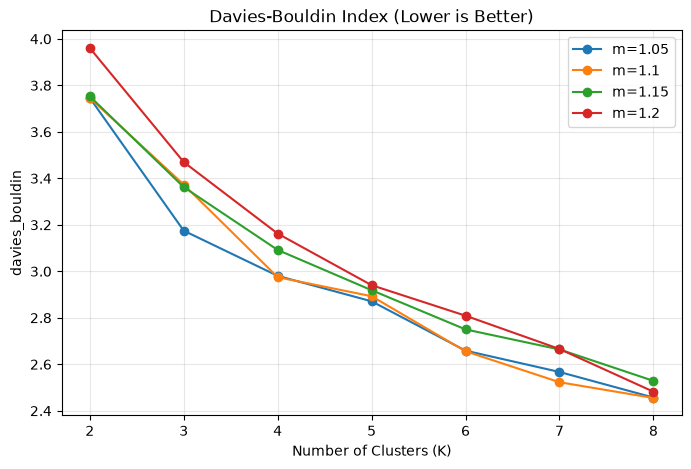

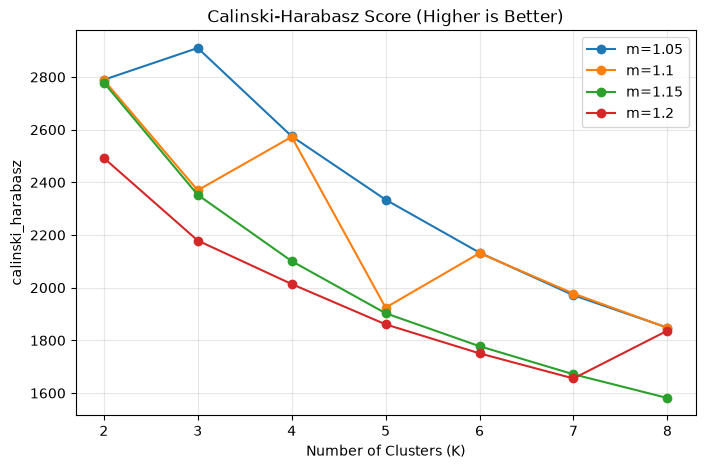

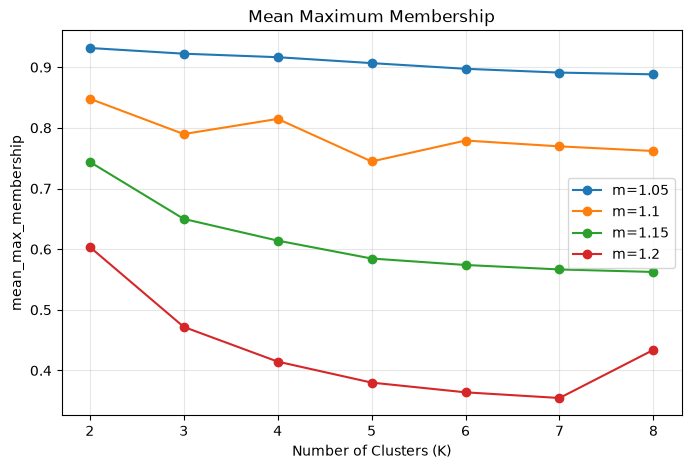

In [28]:
metrics_to_plot = [
    ("FPC", "Fuzzy Partition Coefficient (Higher is Better)"),
    ("silhouette", "Silhouette Score (Higher is Better)"),
    ("davies_bouldin", "Davies-Bouldin Index (Lower is Better)"),
    ("calinski_harabasz", "Calinski-Harabasz Score (Higher is Better)"),
    ("mean_max_membership", "Mean Maximum Membership")
]

for metric, title in metrics_to_plot:

    plt.figure(figsize=(8, 5))

    for m_value in m_values:
        subset = fcm_results_df[
            fcm_results_df["m"] == m_value
        ]

        plt.plot(
            subset["K"],
            subset[metric],
            marker="o",
            label=f"m={m_value}"
        )

    plt.xlabel("Number of Clusters (K)")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [29]:
fcm_results_df["converged"] = (
    fcm_results_df["iterations"] < 1000
)

display(
    fcm_results_df[
        [
            "K", "m", "iterations",
            "converged", "FPC",
            "silhouette",
            "davies_bouldin",
            "mean_max_membership"
        ]
    ]
)

,K,m,iterations,converged,FPC,silhouette,davies_bouldin,mean_max_membership
0,2,1.05,51,True,0.900721,0.064964,3.745992,0.931630
1,2,1.10,73,True,0.780628,0.064900,3.746448,0.847971
2,2,1.15,159,True,0.648743,0.064445,3.752852,0.743877
3,2,1.20,1000,False,0.531757,0.058392,3.960760,0.603648
4,3,1.05,59,True,0.898505,0.073911,3.174785,0.922260
5,3,1.10,257,True,0.701018,0.054740,3.373019,0.789743
6,3,1.15,479,True,0.529161,0.054306,3.362326,0.649886
7,3,1.20,408,True,0.378513,0.050988,3.469972,0.471861
8,4,1.05,192,True,0.879886,0.062970,2.980423,0.916462
9,4,1.10,330,True,0.734695,0.062982,2.974649,0.814752


In [30]:
print("Highest Silhouette:")
display(
    fcm_results_df.nlargest(
        5, "silhouette"
    )[
        ["K", "m", "silhouette", "FPC",
         "davies_bouldin", "mean_max_membership",
         "iterations"]
    ]
)

print("\nLowest Davies-Bouldin:")
display(
    fcm_results_df.nsmallest(
        5, "davies_bouldin"
    )[
        ["K", "m", "davies_bouldin",
         "silhouette", "FPC",
         "mean_max_membership", "iterations"]
    ]
)

print("\nHighest FPC:")
display(
    fcm_results_df.nlargest(
        5, "FPC"
    )[
        ["K", "m", "FPC",
         "silhouette", "davies_bouldin",
         "mean_max_membership", "iterations"]
    ]
)

Highest Silhouette:


,K,m,silhouette,FPC,davies_bouldin,mean_max_membership,iterations
4,3,1.05,0.073911,0.898505,3.174785,0.922260,59
0,2,1.05,0.064964,0.900721,3.745992,0.931630,51
1,2,1.10,0.064900,0.780628,3.746448,0.847971,73
2,2,1.15,0.064445,0.648743,3.752852,0.743877,159
12,5,1.05,0.063451,0.865836,2.870971,0.906706,372



Lowest Davies-Bouldin:


,K,m,davies_bouldin,silhouette,FPC,mean_max_membership,iterations
25,8,1.10,2.454996,0.060322,0.667360,0.761824,1000
24,8,1.05,2.456886,0.060485,0.841056,0.888199,1000
27,8,1.20,2.482070,0.058787,0.289577,0.433963,676
21,7,1.10,2.522874,0.061075,0.676864,0.769465,487
26,8,1.15,2.528700,0.054910,0.422274,0.562413,1000



Highest FPC:


,K,m,FPC,silhouette,davies_bouldin,mean_max_membership,iterations
0,2,1.05,0.900721,0.064964,3.745992,0.931630,51
4,3,1.05,0.898505,0.073911,3.174785,0.922260,59
8,4,1.05,0.879886,0.062970,2.980423,0.916462,192
12,5,1.05,0.865836,0.063451,2.870971,0.906706,372
16,6,1.05,0.853310,0.061929,2.658660,0.897335,308


Stability Testing

In [31]:
candidate_configs = [
    (3, 1.05),   # highest silhouette
    (4, 1.10),   # balanced candidate
    (6, 1.10),   # more detailed segmentation
    (7, 1.10),   # good DB and converged
    (8, 1.20)    # softer high-K candidate and converged
]

candidate_configs

[(3, 1.05), (4, 1.1), (6, 1.1), (7, 1.1), (8, 1.2)]

In [32]:
from sklearn.metrics import adjusted_rand_score

stability_seeds = [10, 20, 30, 40, 50]

stability_results = []

for k, m_value in candidate_configs:

    print(f"\nTesting stability: K={k}, m={m_value}")

    labels_by_seed = {}
    fpc_by_seed = {}

    for seed in stability_seeds:

        cntr_seed, u_seed, _, _, _, iterations_seed, fpc_seed = (
            fuzz.cluster.cmeans(
                X_dev_fcm,
                c=k,
                m=m_value,
                error=0.005,
                maxiter=1000,
                init=None,
                seed=seed
            )
        )

        labels_by_seed[seed] = np.argmax(u_seed, axis=0)
        fpc_by_seed[seed] = fpc_seed

    # Pairwise ARI between seeds
    ari_scores = []

    for i in range(len(stability_seeds)):
        for j in range(i + 1, len(stability_seeds)):

            seed_a = stability_seeds[i]
            seed_b = stability_seeds[j]

            ari = adjusted_rand_score(
                labels_by_seed[seed_a],
                labels_by_seed[seed_b]
            )

            ari_scores.append(ari)

    stability_results.append({
        "K": k,
        "m": m_value,
        "mean_ARI": np.mean(ari_scores),
        "min_ARI": np.min(ari_scores),
        "max_ARI": np.max(ari_scores),
        "std_ARI": np.std(ari_scores),
        "mean_FPC": np.mean(list(fpc_by_seed.values())),
        "std_FPC": np.std(list(fpc_by_seed.values()))
    })

stability_df = pd.DataFrame(stability_results)

display(stability_df)


Testing stability: K=3, m=1.05

Testing stability: K=4, m=1.1

Testing stability: K=6, m=1.1

Testing stability: K=7, m=1.1

Testing stability: K=8, m=1.2


,K,m,mean_ARI,min_ARI,max_ARI,std_ARI,mean_FPC,std_FPC
0,3,1.05,0.196290,0.001815,1.000000,0.291883,0.880501,0.023207
1,4,1.10,0.100147,0.007487,0.265565,0.082197,0.664865,0.001928
2,6,1.10,0.132258,0.078583,0.241358,0.062333,0.665037,0.028452
3,7,1.10,0.171575,0.101642,0.248288,0.054338,0.654972,0.025923
4,8,1.20,0.253756,0.145553,0.405521,0.085505,0.219810,0.000457


In [33]:
stability_path = RESULTS_DIR / "fcm_stability_results.csv"

stability_df.to_csv(
    stability_path,
    index=False
)

print("Saved:", stability_path)

Saved: c:\Users\ASUS\Pictures\final fdm\results\fcm_stability_results.csv


K-Means-informed initialization

In [34]:
from sklearn.cluster import KMeans

def create_kmeans_fuzzy_init(X, k, epsilon=1e-6):
    """
    Create an initial fuzzy membership matrix using K-Means labels.
    FCM expects shape: (clusters, samples)
    """

    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )

    labels = km.fit_predict(X)

    n_samples = X.shape[0]

    # Small membership for non-selected clusters
    init_u = np.full(
        (k, n_samples),
        epsilon,
        dtype=float
    )

    # High initial membership for K-Means assigned cluster
    init_u[labels, np.arange(n_samples)] = 1.0

    # Normalize so memberships sum to 1
    init_u /= init_u.sum(axis=0, keepdims=True)

    return init_u

In [35]:
initialized_results = []

for k, m_value in candidate_configs:

    print(f"Running K={k}, m={m_value}")

    init_u = create_kmeans_fuzzy_init(
        X_dev_array,
        k
    )

    cntr_init, u_init, _, _, _, iterations_init, fpc_init = (
        fuzz.cluster.cmeans(
            X_dev_fcm,
            c=k,
            m=m_value,
            error=0.005,
            maxiter=1000,
            init=init_u
        )
    )

    labels_init = np.argmax(u_init, axis=0)

    silhouette_init = silhouette_score(
        X_dev_array[silhouette_idx],
        labels_init[silhouette_idx]
    )

    db_init = davies_bouldin_score(
        X_dev_array,
        labels_init
    )

    ch_init = calinski_harabasz_score(
        X_dev_array,
        labels_init
    )

    max_membership_init = np.max(
        u_init,
        axis=0
    )

    initialized_results.append({
        "K": k,
        "m": m_value,
        "FPC": fpc_init,
        "silhouette": silhouette_init,
        "davies_bouldin": db_init,
        "calinski_harabasz": ch_init,
        "mean_max_membership":
            max_membership_init.mean(),
        "iterations": iterations_init,
        "converged": iterations_init < 1000
    })

initialized_df = pd.DataFrame(
    initialized_results
)

display(initialized_df)

Running K=3, m=1.05
Running K=4, m=1.1
Running K=6, m=1.1
Running K=7, m=1.1
Running K=8, m=1.2


,K,m,FPC,silhouette,davies_bouldin,calinski_harabasz,mean_max_membership,iterations,converged
0,3,1.05,0.898506,0.073911,3.174767,2910.080682,0.922262,35,True
1,4,1.10,0.731309,0.064314,2.978749,2558.748651,0.812413,150,True
2,6,1.10,0.687550,0.061362,2.638209,2128.937094,0.777710,750,True
3,7,1.10,0.676625,0.060858,2.539287,1974.681510,0.769076,769,True
4,8,1.20,0.289749,0.059561,2.446475,1838.850122,0.434449,1000,False


In [36]:
initialized_df.to_csv(
    RESULTS_DIR / "fcm_kmeans_initialized_results.csv",
    index=False
)

In [37]:
final_candidates = [
    (3, 1.05),
    (4, 1.10),
    (7, 1.10)
]

In [38]:
final_stability_results = []

rng = np.random.default_rng(42)

for k, m_value in final_candidates:

    base_init = create_kmeans_fuzzy_init(
        X_dev_array,
        k
    )

    labels_runs = []
    fpc_runs = []
    iterations_runs = []

    for run in range(5):

        # Add very small noise to informed initialization
        noise = rng.normal(
            0,
            0.001,
            size=base_init.shape
        )

        perturbed_init = base_init + noise

        # Memberships cannot be negative
        perturbed_init = np.clip(
            perturbed_init,
            1e-10,
            None
        )

        # Re-normalize memberships for each customer
        perturbed_init /= perturbed_init.sum(
            axis=0,
            keepdims=True
        )

        cntr_run, u_run, _, _, _, iterations_run, fpc_run = (
            fuzz.cluster.cmeans(
                X_dev_fcm,
                c=k,
                m=m_value,
                error=0.005,
                maxiter=1000,
                init=perturbed_init
            )
        )

        labels_runs.append(
            np.argmax(u_run, axis=0)
        )

        fpc_runs.append(fpc_run)
        iterations_runs.append(iterations_run)

    # Pairwise ARI
    ari_values = []

    for i in range(len(labels_runs)):
        for j in range(i + 1, len(labels_runs)):

            ari_values.append(
                adjusted_rand_score(
                    labels_runs[i],
                    labels_runs[j]
                )
            )

    final_stability_results.append({
        "K": k,
        "m": m_value,

        "mean_ARI":
            np.mean(ari_values),

        "min_ARI":
            np.min(ari_values),

        "std_ARI":
            np.std(ari_values),

        "mean_FPC":
            np.mean(fpc_runs),

        "std_FPC":
            np.std(fpc_runs),

        "mean_iterations":
            np.mean(iterations_runs),

        "max_iterations":
            np.max(iterations_runs),

        "all_converged":
            all(i < 1000 for i in iterations_runs)
    })

final_stability_df = pd.DataFrame(
    final_stability_results
)

display(final_stability_df)

,K,m,mean_ARI,min_ARI,std_ARI,mean_FPC,std_FPC,mean_iterations,max_iterations,all_converged
0,3,1.05,1.0,1.0,0.0,0.898506,5.118656e-11,35.0,35,True
1,4,1.10,1.0,1.0,0.0,0.731309,6.013671e-10,150.0,150,True
2,7,1.10,1.0,1.0,0.0,0.676625,2.514757e-10,769.0,769,True


In [39]:
final_stability_df.to_csv(
    RESULTS_DIR / "fcm_final_robustness.csv",
    index=False
)

## Final FCM Configuration Selection

After baseline testing, fuzziness diagnostics, joint K-m experiments,
convergence analysis, random-initialization stability testing, and
K-Means-informed initialization robustness testing, the configuration
K=4 and m=1.10 was selected as the FCM model to carry forward.

K=3, m=1.05 achieved the highest Silhouette Score and high FPC, but its
mean maximum membership was approximately 0.92, indicating relatively
crisp assignments that provide less useful soft-membership information
for the project's ambiguity objective.

Higher-K solutions provided improvements in some separation measures,
but increased computational cost and segmentation complexity. For
example, K=7, m=1.10 required substantially more iterations.

K=4, m=1.10 provided a practical balance between cluster separation,
fuzzy membership information, convergence, computational cost,
robustness, and business interpretability.

The selected configuration should therefore be interpreted as a
balanced project-specific choice rather than a universally optimal
clustering solution.

create the final development FCM

In [40]:
FINAL_K = 4
FINAL_M = 1.10

final_init = create_kmeans_fuzzy_init(
    X_dev_array,
    FINAL_K
)

final_centers, final_u_dev, _, _, final_jm, final_iterations, final_fpc = (
    fuzz.cluster.cmeans(
        X_dev_fcm,
        c=FINAL_K,
        m=FINAL_M,
        error=0.005,
        maxiter=1000,
        init=final_init
    )
)

final_dev_labels = np.argmax(
    final_u_dev,
    axis=0
)

print("Final K:", FINAL_K)
print("Final m:", FINAL_M)
print("Iterations:", final_iterations)
print("FPC:", round(final_fpc, 6))
print("Centers shape:", final_centers.shape)
print("Membership matrix:", final_u_dev.shape)

Final K: 4
Final m: 1.1
Iterations: 150
FPC: 0.731309
Centers shape: (4, 18)
Membership matrix: (4, 40000)


In [41]:
X_holdout_array = X_holdout.to_numpy()
X_holdout_fcm = X_holdout_array.T

print("Normal holdout shape:", X_holdout_array.shape)
print("FCM holdout shape:", X_holdout_fcm.shape)

Normal holdout shape: (10000, 18)
FCM holdout shape: (18, 10000)


In [42]:
holdout_u, holdout_u0, holdout_d, holdout_jm, holdout_iterations, holdout_fpc = (
    fuzz.cluster.cmeans_predict(
        X_holdout_fcm,
        final_centers,
        m=FINAL_M,
        error=0.005,
        maxiter=1000,
        init=None,
        seed=42
    )
)

holdout_labels = np.argmax(
    holdout_u,
    axis=0
)

print("Holdout membership shape:", holdout_u.shape)
print("Holdout iterations:", holdout_iterations)
print("Holdout FPC:", round(holdout_fpc, 6))

print(
    "Membership sums valid:",
    np.allclose(
        holdout_u.sum(axis=0),
        1.0
    )
)

Holdout membership shape: (4, 10000)
Holdout iterations: 2
Holdout FPC: 0.72966
Membership sums valid: True


In [43]:
holdout_silhouette = silhouette_score(
    X_holdout_array,
    holdout_labels
)

holdout_db = davies_bouldin_score(
    X_holdout_array,
    holdout_labels
)

holdout_ch = calinski_harabasz_score(
    X_holdout_array,
    holdout_labels
)

holdout_max_membership = np.max(
    holdout_u,
    axis=0
)

print("HOLDOUT RESULTS")
print("------------------------------")
print(f"Silhouette Score:       {holdout_silhouette:.6f}")
print(f"Davies-Bouldin Index:   {holdout_db:.6f}")
print(f"Calinski-Harabasz:      {holdout_ch:.6f}")
print(f"FPC:                    {holdout_fpc:.6f}")
print(
    f"Mean Maximum Membership: "
    f"{holdout_max_membership.mean():.6f}"
)

HOLDOUT RESULTS
------------------------------
Silhouette Score:       0.061701
Davies-Bouldin Index:   2.979027
Calinski-Harabasz:      642.931401
FPC:                    0.729660
Mean Maximum Membership: 0.811196


In [44]:
dev_silhouette = silhouette_score(
    X_dev_array[silhouette_idx],
    final_dev_labels[silhouette_idx]
)

dev_db = davies_bouldin_score(
    X_dev_array,
    final_dev_labels
)

dev_ch = calinski_harabasz_score(
    X_dev_array,
    final_dev_labels
)

dev_max_membership = np.max(
    final_u_dev,
    axis=0
)

comparison_df = pd.DataFrame({
    "Metric": [
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz",
        "FPC",
        "Mean Max Membership"
    ],

    "Development": [
        dev_silhouette,
        dev_db,
        dev_ch,
        final_fpc,
        dev_max_membership.mean()
    ],

    "Holdout": [
        holdout_silhouette,
        holdout_db,
        holdout_ch,
        holdout_fpc,
        holdout_max_membership.mean()
    ]
})

display(comparison_df)

,Metric,Development,Holdout
0,Silhouette,0.064314,0.061701
1,Davies-Bouldin,2.978749,2.979027
2,Calinski-Harabasz,2558.748651,642.931401
3,FPC,0.731309,0.729660
4,Mean Max Membership,0.812413,0.811196


In [45]:
dev_cluster_sizes = np.bincount(
    final_dev_labels,
    minlength=FINAL_K
)

holdout_cluster_sizes = np.bincount(
    holdout_labels,
    minlength=FINAL_K
)

cluster_distribution_df = pd.DataFrame({
    "Cluster": np.arange(1, FINAL_K + 1),

    "Development_Count":
        dev_cluster_sizes,

    "Development_Percent":
        dev_cluster_sizes / len(final_dev_labels) * 100,

    "Holdout_Count":
        holdout_cluster_sizes,

    "Holdout_Percent":
        holdout_cluster_sizes / len(holdout_labels) * 100
})

display(cluster_distribution_df)

,Cluster,Development_Count,Development_Percent,Holdout_Count,Holdout_Percent
0,1,5731,14.3275,1483,14.83
1,2,10836,27.0900,2641,26.41
2,3,12471,31.1775,3059,30.59
3,4,10962,27.4050,2817,28.17


In [46]:
holdout_membership_preview = pd.DataFrame({
    "customer_id": holdout_ids.values
})

for cluster_idx in range(FINAL_K):

    holdout_membership_preview[
        f"cluster_{cluster_idx + 1}_membership"
    ] = holdout_u[cluster_idx]

holdout_membership_preview[
    "assigned_cluster"
] = holdout_labels + 1

holdout_membership_preview[
    "max_membership"
] = holdout_max_membership

display(
    holdout_membership_preview.head(10)
)

,customer_id,cluster_1_membership,cluster_2_membership,cluster_3_membership,cluster_4_membership,assigned_cluster,max_membership
0,CUST-000005,0.000849,0.774176,0.015216,0.209758,2,0.774176
1,CUST-000007,0.000136,0.006404,0.006538,0.986922,4,0.986922
2,CUST-000008,0.000069,0.979889,0.018418,0.001624,2,0.979889
3,CUST-000039,0.000232,0.037172,0.002988,0.959608,4,0.959608
4,CUST-000041,0.001731,0.065024,0.875331,0.057914,3,0.875331
5,CUST-000050,0.000699,0.952836,0.015866,0.030599,2,0.952836
6,CUST-000062,0.999162,0.000578,0.000068,0.000192,1,0.999162
7,CUST-000063,0.008319,0.429858,0.044699,0.517123,4,0.517123
8,CUST-000071,0.000100,0.004027,0.007814,0.988060,4,0.988060
9,CUST-000072,0.998384,0.001148,0.000112,0.000356,1,0.998384


In [47]:
comparison_df.to_csv(
    RESULTS_DIR / "fcm_development_holdout_comparison.csv",
    index=False
)

cluster_distribution_df.to_csv(
    RESULTS_DIR / "fcm_cluster_distributions.csv",
    index=False
)

holdout_membership_preview.to_csv(
    RESULTS_DIR / "fcm_holdout_memberships.csv",
    index=False
)

print("FCM holdout results saved successfully.")

FCM holdout results saved successfully.


In [48]:
import joblib

fcm_artifact = {
    "algorithm": "Fuzzy C-Means",
    "n_clusters": FINAL_K,
    "m": FINAL_M,
    "error": 0.005,
    "maxiter": 1000,

    "centers": final_centers,

    "feature_names": X_dev.columns.tolist(),

    "development_fpc": final_fpc,

    "initialization":
        "K-Means-informed initialization",

    "preprocessing":
        "models/modelling_preprocessor.pkl"
}

fcm_model_path = (
    MODELS_DIR / "final_fcm_model.pkl"
)

joblib.dump(
    fcm_artifact,
    fcm_model_path
)

print("Saved:", fcm_model_path)

Saved: c:\Users\ASUS\Pictures\final fdm\models\final_fcm_model.pkl


In [49]:
development_memberships_df = pd.DataFrame({
    "customer_id": development_ids.values
})

for cluster_idx in range(FINAL_K):
    development_memberships_df[
        f"cluster_{cluster_idx + 1}_membership"
    ] = final_u_dev[cluster_idx]

development_memberships_df[
    "assigned_cluster"
] = final_dev_labels + 1

development_memberships_df[
    "max_membership"
] = np.max(
    final_u_dev,
    axis=0
)

development_memberships_df.to_csv(
    RESULTS_DIR / "fcm_development_memberships.csv",
    index=False
)

display(
    development_memberships_df.head()
)

,customer_id,cluster_1_membership,cluster_2_membership,cluster_3_membership,cluster_4_membership,assigned_cluster,max_membership
0,CUST-000001,0.011244,0.040699,0.017737,0.930320,4,0.930320
1,CUST-000002,0.979630,0.014919,0.003786,0.001665,1,0.979630
2,CUST-000003,0.002256,0.043667,0.950386,0.003691,3,0.950386
3,CUST-000004,0.000132,0.003518,0.990960,0.005389,3,0.990960
4,CUST-000006,0.000801,0.810517,0.172988,0.015694,2,0.810517


## FCM Cluster Profiling and Interpretation

The selected FCM configuration is now profiled to understand the
customer characteristics represented by each cluster.

Cluster formation was performed using the preprocessed feature matrix.
For interpretation, the original-scale development data is joined with
the FCM cluster assignments using `customer_id`.

This analysis is specific to the FCM model. These clusters are not yet
treated as the final system segments because the final algorithm will
be selected after comparison with K-Means, GMM, and Agglomerative
Clustering.

In [50]:
development_raw = pd.read_csv(
    DATA_DIR / "development_raw.csv"
)

print("Raw development shape:", development_raw.shape)
display(development_raw.head())

Raw development shape: (40000, 13)


,customer_id,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,shopping_channel,device_used
0,CUST-000001,77,28,912.60,63,15,13,5,0.018,0.067,0.022,In-Store,Tablet
1,CUST-000002,80,75,300.86,342,1,14,5,0.084,0.085,0.293,Marketplace,Desktop
2,CUST-000003,86,163,663.91,64,1,4,3,0.279,0.428,0.222,In-Store,Tablet
3,CUST-000004,26,192,613.60,2,11,8,5,0.899,0.282,0.142,Online,Mobile
4,CUST-000006,94,111,423.50,2,16,5,5,0.159,0.148,0.264,In-Store,Multiple


In [51]:
print(
    "FCM membership customers:",
    len(development_memberships_df)
)

print(
    "Raw development customers:",
    len(development_raw)
)

print(
    "Unique membership IDs:",
    development_memberships_df["customer_id"].nunique()
)

print(
    "Unique raw IDs:",
    development_raw["customer_id"].nunique()
)

FCM membership customers: 40000
Raw development customers: 40000
Unique membership IDs: 40000
Unique raw IDs: 40000


In [52]:
fcm_profile_df = development_raw.merge(
    development_memberships_df[
        [
            "customer_id",
            "assigned_cluster",
            "max_membership"
        ]
    ],
    on="customer_id",
    how="inner",
    validate="one_to_one"
)

print("Profile dataset shape:", fcm_profile_df.shape)

print(
    "Customers lost during merge:",
    len(development_raw) - len(fcm_profile_df)
)

display(fcm_profile_df.head())

Profile dataset shape: (40000, 15)
Customers lost during merge: 0


,customer_id,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,shopping_channel,device_used,assigned_cluster,max_membership
0,CUST-000001,77,28,912.60,63,15,13,5,0.018,0.067,0.022,In-Store,Tablet,4,0.930320
1,CUST-000002,80,75,300.86,342,1,14,5,0.084,0.085,0.293,Marketplace,Desktop,1,0.979630
2,CUST-000003,86,163,663.91,64,1,4,3,0.279,0.428,0.222,In-Store,Tablet,3,0.950386
3,CUST-000004,26,192,613.60,2,11,8,5,0.899,0.282,0.142,Online,Mobile,3,0.990960
4,CUST-000006,94,111,423.50,2,16,5,5,0.159,0.148,0.264,In-Store,Multiple,2,0.810517


In [53]:
profile_numeric_features = [
    "tenure_months",
    "total_purchases",
    "avg_order_value_usd",
    "days_since_last_purchase",
    "return_count",
    "complaint_count",
    "satisfaction_score",
    "email_open_rate",
    "click_through_rate",
    "conversion_rate"
]

cluster_numeric_profile = (
    fcm_profile_df
    .groupby("assigned_cluster")[profile_numeric_features]
    .mean()
    .round(3)
)

display(cluster_numeric_profile)

,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate
assigned_cluster,,,,,,,,,,
1,60.484,99.337,498.801,266.226,9.497,6.980,3.024,0.506,0.252,0.150
2,58.873,62.334,500.717,28.319,9.607,7.112,2.978,0.494,0.251,0.230
3,59.354,161.311,511.833,29.104,8.865,6.767,3.090,0.502,0.251,0.155
4,60.387,66.005,504.752,28.579,10.176,7.150,2.947,0.501,0.252,0.068


In [54]:
overall_means = (
    fcm_profile_df[profile_numeric_features]
    .mean()
)

relative_profile = (
    cluster_numeric_profile
    .divide(overall_means)
)

display(relative_profile.round(2))

,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate
assigned_cluster,,,,,,,,,,
1,1.01,1.00,0.99,4.24,1.00,1.00,1.00,1.01,1.0,1.00
2,0.99,0.63,0.99,0.45,1.01,1.02,0.99,0.99,1.0,1.53
3,0.99,1.62,1.01,0.46,0.93,0.97,1.03,1.00,1.0,1.03
4,1.01,0.66,1.00,0.46,1.07,1.02,0.98,1.00,1.0,0.45


In [55]:
channel_profile = pd.crosstab(
    fcm_profile_df["assigned_cluster"],
    fcm_profile_df["shopping_channel"],
    normalize="index"
) * 100

device_profile = pd.crosstab(
    fcm_profile_df["assigned_cluster"],
    fcm_profile_df["device_used"],
    normalize="index"
) * 100

print("Shopping Channel Distribution (%)")
display(channel_profile.round(2))

print("Device Distribution (%)")
display(device_profile.round(2))

Shopping Channel Distribution (%)


shopping_channel,In-Store,Marketplace,Mobile App,Online
assigned_cluster,,,,
1,25.23,25.11,24.74,24.92
2,25.33,24.19,25.18,25.30
3,24.59,24.60,25.42,25.39
4,25.62,24.57,24.84,24.97


Device Distribution (%)


device_used,Desktop,Mobile,Multiple,Tablet
assigned_cluster,,,,
1,25.41,24.53,24.50,25.56
2,25.22,24.34,25.77,24.67
3,25.62,25.12,24.55,24.71
4,25.42,24.38,24.77,25.43


In [56]:
membership_profile = (
    fcm_profile_df
    .groupby("assigned_cluster")["max_membership"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max",
        "std"
    ])
    .round(4)
)

display(membership_profile)

,count,mean,median,min,max,std
assigned_cluster,,,,,,
1,5731,0.8998,0.9767,0.2914,1.0000,0.1488
2,10836,0.8043,0.8538,0.2965,0.9999,0.1656
3,12471,0.7900,0.8305,0.2925,0.9999,0.1590
4,10962,0.8003,0.8504,0.2859,1.0000,0.1668


In [57]:
development_business = pd.read_csv(
    DATA_DIR / "development_business_data.csv"
)

print("Business data shape:", development_business.shape)
display(development_business.head())

Business data shape: (40000, 3)


,customer_id,customer_lifetime_value_usd,churn_risk_score
0,CUST-000001,21281.07,39
1,CUST-000002,28347.21,42
2,CUST-000003,103909.84,0
3,CUST-000004,171318.41,14
4,CUST-000006,52302.46,5


In [58]:
fcm_business_profile = (
    development_memberships_df
    .merge(
        development_business,
        on="customer_id",
        how="inner",
        validate="one_to_one"
    )
)

print("Merged customers:", len(fcm_business_profile))

Merged customers: 40000


In [59]:
business_cluster_summary = (
    fcm_business_profile
    .groupby("assigned_cluster")[
        [
            "customer_lifetime_value_usd",
            "churn_risk_score"
        ]
    ]
    .agg(["mean", "median"])
    .round(3)
)

display(business_cluster_summary)

customer_lifetime_value_usd           churn_risk_score       
                                        mean    median             mean median
assigned_cluster                                                              
1                                  56615.945  41601.96           45.788   45.0
2                                  35480.900  25953.72           24.412   23.0
3                                  94795.908  90400.45           21.553   20.0
4                                  38316.520  27221.73           25.164   23.0

In [60]:
business_means = development_business[
    [
        "customer_lifetime_value_usd",
        "churn_risk_score"
    ]
].mean()

business_relative = (
    fcm_business_profile
    .groupby("assigned_cluster")[
        [
            "customer_lifetime_value_usd",
            "churn_risk_score"
        ]
    ]
    .mean()
    .divide(business_means)
    .round(2)
)

display(business_relative)

,customer_lifetime_value_usd,churn_risk_score
assigned_cluster,,
1,0.98,1.71
2,0.61,0.91
3,1.64,0.80
4,0.66,0.94


In [61]:
cluster_names = {
    1: "Inactive / High-Churn-Risk Customers",
    2: "Low-Purchase High-Conversion Customers",
    3: "High-Value Active Customers",
    4: "Low-Engagement Customers"
}

fcm_profile_df["cluster_name"] = (
    fcm_profile_df["assigned_cluster"]
    .map(cluster_names)
)

development_memberships_df["cluster_name"] = (
    development_memberships_df["assigned_cluster"]
    .map(cluster_names)
)

display(
    development_memberships_df[
        [
            "customer_id",
            "assigned_cluster",
            "cluster_name",
            "max_membership"
        ]
    ].head(10)
)

,customer_id,assigned_cluster,cluster_name,max_membership
0,CUST-000001,4,Low-Engagement Customers,0.930320
1,CUST-000002,1,Inactive / High-Churn-Risk Customers,0.979630
2,CUST-000003,3,High-Value Active Customers,0.950386
3,CUST-000004,3,High-Value Active Customers,0.990960
4,CUST-000006,2,Low-Purchase High-Conversion Customers,0.810517
5,CUST-000009,4,Low-Engagement Customers,0.460559
6,CUST-000010,4,Low-Engagement Customers,0.543533
7,CUST-000011,2,Low-Purchase High-Conversion Customers,0.555692
8,CUST-000012,3,High-Value Active Customers,0.960193
9,CUST-000013,2,Low-Purchase High-Conversion Customers,0.967187


In [62]:
cluster_summary_df = pd.DataFrame({
    "cluster": [1, 2, 3, 4],

    "cluster_name": [
        "Inactive / High-Churn-Risk Customers",
        "Low-Purchase High-Conversion Customers",
        "High-Value Active Customers",
        "Low-Engagement Customers"
    ],

    "main_characteristic": [
        "Very long time since last purchase and elevated churn risk",
        "Lower purchase volume but comparatively high conversion",
        "High purchase volume, high CLV and recent activity",
        "Lower purchase volume and comparatively low conversion"
    ]
})

display(cluster_summary_df)

cluster_summary_df.to_csv(
    RESULTS_DIR / "fcm_cluster_profiles.csv",
    index=False
)

,cluster,cluster_name,main_characteristic
0,1,Inactive / High-Churn-Risk Customers,Very long time since last purchase and elevate...
1,2,Low-Purchase High-Conversion Customers,Lower purchase volume but comparatively high c...
2,3,High-Value Active Customers,"High purchase volume, high CLV and recent acti..."
3,4,Low-Engagement Customers,Lower purchase volume and comparatively low co...


Create the complete membership table

In [63]:
membership_cols = [
    "cluster_1_membership",
    "cluster_2_membership",
    "cluster_3_membership",
    "cluster_4_membership"
]

display(
    development_memberships_df[
        ["customer_id"] + membership_cols +
        ["assigned_cluster", "max_membership"]
    ].head(10)
)

,customer_id,cluster_1_membership,cluster_2_membership,cluster_3_membership,cluster_4_membership,assigned_cluster,max_membership
0,CUST-000001,0.011244,0.040699,0.017737,0.930320,4,0.930320
1,CUST-000002,0.979630,0.014919,0.003786,0.001665,1,0.979630
2,CUST-000003,0.002256,0.043667,0.950386,0.003691,3,0.950386
3,CUST-000004,0.000132,0.003518,0.990960,0.005389,3,0.990960
4,CUST-000006,0.000801,0.810517,0.172988,0.015694,2,0.810517
5,CUST-000009,0.011027,0.126137,0.402278,0.460559,4,0.460559
6,CUST-000010,0.049736,0.337122,0.069610,0.543533,4,0.543533
7,CUST-000011,0.001338,0.555692,0.020689,0.422281,2,0.555692
8,CUST-000012,0.001972,0.037387,0.960193,0.000447,3,0.960193
9,CUST-000013,0.000776,0.967187,0.017586,0.014452,2,0.967187


In [64]:
membership_sums = (
    development_memberships_df[membership_cols]
    .sum(axis=1)
)

print(
    "All membership sums approximately 1:",
    np.allclose(membership_sums, 1.0)
)

All membership sums approximately 1: True


In [65]:
membership_values = (
    development_memberships_df[membership_cols]
    .to_numpy()
)

sorted_memberships = np.sort(
    membership_values,
    axis=1
)

development_memberships_df[
    "membership_margin"
] = (
    sorted_memberships[:, -1]
    - sorted_memberships[:, -2]
)

In [66]:
epsilon = 1e-12

entropy = -np.sum(
    membership_values *
    np.log(membership_values + epsilon),
    axis=1
)

normalized_entropy = (
    entropy / np.log(FINAL_K)
)

development_memberships_df[
    "normalized_entropy"
] = normalized_entropy

In [67]:
uncertainty_summary = (
    development_memberships_df[
        [
            "max_membership",
            "membership_margin",
            "normalized_entropy"
        ]
    ]
    .describe()
    .round(4)
)

display(uncertainty_summary)

,max_membership,membership_margin,normalized_entropy
count,40000.0000,40000.0000,40000.0000
mean,0.8124,0.6645,0.3487
std,0.1656,0.2974,0.2247
min,0.2859,0.0000,0.0001
25%,0.6901,0.4395,0.1477
50%,0.8637,0.7581,0.3376
75%,0.9570,0.9264,0.5312
max,1.0000,1.0000,0.9955


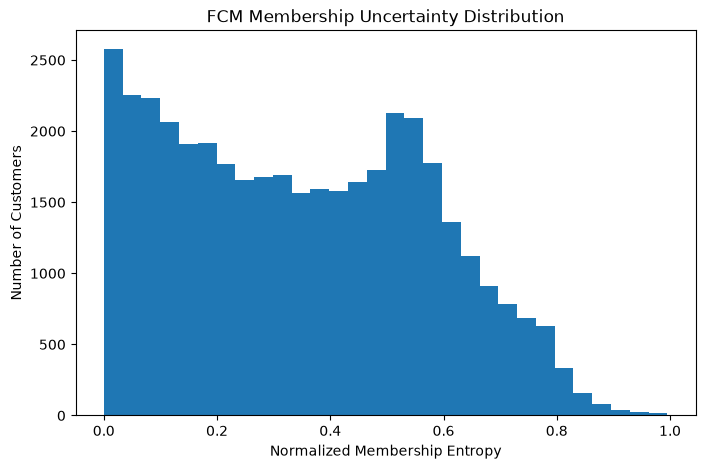

In [68]:
plt.figure(figsize=(8, 5))

plt.hist(
    development_memberships_df["normalized_entropy"],
    bins=30
)

plt.xlabel("Normalized Membership Entropy")
plt.ylabel("Number of Customers")
plt.title("FCM Membership Uncertainty Distribution")

plt.show()

In [69]:
most_ambiguous = (
    development_memberships_df
    .sort_values(
        "normalized_entropy",
        ascending=False
    )
    .head(10)
)

display(
    most_ambiguous[
        ["customer_id"] +
        membership_cols +
        [
            "assigned_cluster",
            "max_membership",
            "membership_margin",
            "normalized_entropy"
        ]
    ]
)

,customer_id,cluster_1_membership,cluster_2_membership,cluster_3_membership,cluster_4_membership,assigned_cluster,max_membership,membership_margin,normalized_entropy
18088,CUST-022667,0.262444,0.241732,0.209974,0.285851,4,0.285851,0.023407,0.995463
12890,CUST-016138,0.257652,0.235390,0.292507,0.214451,3,0.292507,0.034854,0.995216
6676,CUST-008398,0.226551,0.296528,0.262309,0.214613,2,0.296528,0.034219,0.994121
24222,CUST-030338,0.234187,0.317084,0.233320,0.215409,2,0.317084,0.082897,0.991430
6598,CUST-008300,0.291391,0.282203,0.181046,0.245359,1,0.291391,0.009188,0.988593
4831,CUST-006067,0.304563,0.262670,0.276655,0.156113,1,0.304563,0.027908,0.980070
546,CUST-000678,0.291460,0.320133,0.223861,0.164546,2,0.320133,0.028673,0.978117
22071,CUST-027608,0.173116,0.263269,0.220279,0.343336,4,0.343336,0.080067,0.977611
9801,CUST-012261,0.204248,0.196064,0.368859,0.230829,3,0.368859,0.138030,0.973944
39646,CUST-049571,0.186779,0.185721,0.358131,0.269369,3,0.358131,0.088762,0.971741


In [70]:
clearest_customers = (
    development_memberships_df
    .sort_values(
        "normalized_entropy",
        ascending=True
    )
    .head(10)
)

display(
    clearest_customers[
        ["customer_id"] +
        membership_cols +
        [
            "assigned_cluster",
            "max_membership",
            "membership_margin",
            "normalized_entropy"
        ]
    ]
)

,customer_id,cluster_1_membership,cluster_2_membership,cluster_3_membership,cluster_4_membership,assigned_cluster,max_membership,membership_margin,normalized_entropy
31170,CUST-039046,0.999995,0.000001,2.430454e-06,0.000001,1,0.999995,0.999993,0.000051
15546,CUST-019486,0.999994,0.000003,3.059562e-07,0.000002,1,0.999994,0.999991,0.000057
8424,CUST-010570,0.999992,0.000002,1.220399e-06,0.000005,1,0.999992,0.999987,0.000083
36959,CUST-046225,0.999990,0.000004,2.286775e-06,0.000003,1,0.999990,0.999986,0.000095
8698,CUST-010913,0.999987,0.000007,2.110692e-06,0.000004,1,0.999987,0.999980,0.000122
27819,CUST-034864,0.999978,0.000004,4.077561e-06,0.000014,1,0.999978,0.999964,0.000201
5518,CUST-006952,0.999976,0.000016,3.205348e-06,0.000004,1,0.999976,0.999960,0.000216
23806,CUST-029815,0.999972,0.000005,1.915852e-05,0.000003,1,0.999972,0.999953,0.000246
22243,CUST-027830,0.999969,0.000015,8.780385e-06,0.000007,1,0.999969,0.999954,0.000275
3241,CUST-004076,0.999967,0.000003,5.646523e-06,0.000024,1,0.999967,0.999943,0.000285


In [71]:
ambiguity_by_cluster = (
    development_memberships_df
    .groupby("assigned_cluster")[
        [
            "max_membership",
            "membership_margin",
            "normalized_entropy"
        ]
    ]
    .mean()
    .round(4)
)

display(ambiguity_by_cluster)

,max_membership,membership_margin,normalized_entropy
assigned_cluster,,,
1,0.8998,0.8273,0.2081
2,0.8043,0.6514,0.3636
3,0.7900,0.6201,0.3841
4,0.8003,0.6427,0.3672


In [72]:
development_memberships_df.to_csv(
    RESULTS_DIR / "fcm_development_memberships_with_uncertainty.csv",
    index=False
)

ambiguity_by_cluster.to_csv(
    RESULTS_DIR / "fcm_uncertainty_by_cluster.csv"
)

print("FCM membership uncertainty results saved.")

FCM membership uncertainty results saved.


# Final FCM Results and Model Freeze

This section consolidates the final results of the Fuzzy C-Means (FCM)
model after model development, hyperparameter investigation, stability
analysis, initialization optimization, holdout evaluation, cluster
profiling, and fuzzy-membership uncertainty analysis.

The selected FCM configuration is:

- Number of clusters (K): 4
- Fuzziness parameter (m): 1.10
- Initialization: K-Means-informed initialization
- Error tolerance: 0.005
- Maximum iterations: 1000

The model was selected as a balanced FCM configuration considering
internal clustering quality, convergence, computational requirements,
membership fuzziness, robustness, and business interpretability.

This is the final FCM configuration for cross-model comparison.
No further FCM tuning will be performed using the holdout data.

In [73]:
fcm_final_summary = pd.DataFrame([{
    "algorithm": "Fuzzy C-Means",
    "K": FINAL_K,
    "m": FINAL_M,
    "initialization": "K-Means-informed",
    
    "development_rows": len(X_dev_array),
    "holdout_rows": len(X_holdout_array),
    "n_features": X_dev_array.shape[1],

    "development_silhouette": dev_silhouette,
    "holdout_silhouette": holdout_silhouette,

    "development_davies_bouldin": dev_db,
    "holdout_davies_bouldin": holdout_db,

    "development_calinski_harabasz": dev_ch,
    "holdout_calinski_harabasz": holdout_ch,

    "development_fpc": final_fpc,
    "holdout_fpc": holdout_fpc,

    "development_mean_max_membership":
        dev_max_membership.mean(),

    "holdout_mean_max_membership":
        holdout_max_membership.mean(),

    "iterations": final_iterations,

    "converged": final_iterations < 1000,

    "robustness_mean_ARI": 1.0,

    "supports_soft_membership": True
}])

display(fcm_final_summary)

,algorithm,K,m,initialization,development_rows,holdout_rows,n_features,development_silhouette,holdout_silhouette,development_davies_bouldin,...,development_calinski_harabasz,holdout_calinski_harabasz,development_fpc,holdout_fpc,development_mean_max_membership,holdout_mean_max_membership,iterations,converged,robustness_mean_ARI,supports_soft_membership
0,Fuzzy C-Means,4,1.1,K-Means-informed,40000,10000,18,0.064314,0.061701,2.978749,...,2558.748651,642.931401,0.731309,0.72966,0.812413,0.811196,150,True,1.0,True


In [74]:
fcm_final_summary.to_csv(
    RESULTS_DIR / "fcm_final_summary.csv",
    index=False
)

print(
    "Saved:",
    RESULTS_DIR / "fcm_final_summary.csv"
)

Saved: c:\Users\ASUS\Pictures\final fdm\results\fcm_final_summary.csv


In [75]:
fcm_cluster_summary = pd.DataFrame({
    "cluster": [1, 2, 3, 4],

    "profile_name": [
        "Inactive / High-Churn-Risk Customers",
        "Low-Purchase High-Conversion Customers",
        "High-Value Active Customers",
        "Low-Engagement Customers"
    ],

    "development_customers": [
        5731,
        10836,
        12471,
        10962
    ],

    "development_percent": [
        14.3275,
        27.0900,
        31.1775,
        27.4050
    ],

    "mean_max_membership": [
        0.8998,
        0.8043,
        0.7900,
        0.8003
    ],

    "mean_normalized_entropy": [
        0.2081,
        0.3636,
        0.3841,
        0.3672
    ],

    "interpretation": [
        "Very long inactivity and elevated churn risk",
        "Lower purchase volume but comparatively high conversion",
        "High purchase volume, high CLV and recent activity",
        "Lower purchase volume and comparatively low conversion"
    ]
})

display(fcm_cluster_summary)

,cluster,profile_name,development_customers,development_percent,mean_max_membership,mean_normalized_entropy,interpretation
0,1,Inactive / High-Churn-Risk Customers,5731,14.3275,0.8998,0.2081,Very long inactivity and elevated churn risk
1,2,Low-Purchase High-Conversion Customers,10836,27.0900,0.8043,0.3636,Lower purchase volume but comparatively high c...
2,3,High-Value Active Customers,12471,31.1775,0.7900,0.3841,"High purchase volume, high CLV and recent acti..."
3,4,Low-Engagement Customers,10962,27.4050,0.8003,0.3672,Lower purchase volume and comparatively low co...


In [76]:
fcm_cluster_summary.to_csv(
    RESULTS_DIR / "fcm_cluster_profiles.csv",
    index=False
)

In [77]:
fcm_comparison_record = pd.DataFrame([{
    "algorithm": "FCM",

    "selected_K": 4,

    "silhouette_dev": round(
        dev_silhouette, 6
    ),

    "silhouette_holdout": round(
        holdout_silhouette, 6
    ),

    "davies_bouldin_dev": round(
        dev_db, 6
    ),

    "davies_bouldin_holdout": round(
        holdout_db, 6
    ),

    "calinski_harabasz_dev": round(
        dev_ch, 6
    ),

    "calinski_harabasz_holdout": round(
        holdout_ch, 6
    ),

    "supports_soft_membership": True,

    "soft_measure": "Fuzzy membership",

    "fpc_dev": round(
        final_fpc, 6
    ),

    "fpc_holdout": round(
        holdout_fpc, 6
    ),

    "converged": True,

    "stability_method":
        "K-Means-informed perturbation robustness",

    "stability_ARI": 1.0,

    "business_interpretable": True
}])

display(fcm_comparison_record)

,algorithm,selected_K,silhouette_dev,silhouette_holdout,davies_bouldin_dev,davies_bouldin_holdout,calinski_harabasz_dev,calinski_harabasz_holdout,supports_soft_membership,soft_measure,fpc_dev,fpc_holdout,converged,stability_method,stability_ARI,business_interpretable
0,FCM,4,0.064314,0.061701,2.978749,2.979027,2558.748651,642.931401,True,Fuzzy membership,0.731309,0.72966,True,K-Means-informed perturbation robustness,1.0,True


In [78]:
fcm_comparison_record.to_csv(
    RESULTS_DIR / "fcm_model_comparison_record.csv",
    index=False
)

## Final FCM Conclusion

The initial FCM experiments demonstrated that conventional fuzziness
settings could lead to nearly identical cluster centers and
approximately equal memberships. Therefore, the fuzziness parameter
and number of clusters were investigated systematically.

Candidate configurations were evaluated using FPC, Silhouette Score,
Davies-Bouldin Index, Calinski-Harabasz Score, membership strength,
convergence behaviour, and cluster distributions.

Random initialization produced sensitivity across repeated runs.
K-Means-informed initialization was therefore evaluated as an
optimization strategy. The informed initialization produced
reproducible solutions under small initialization perturbations.

The final FCM configuration selected for cross-model comparison was
K=4 and m=1.10.

On the development data, the selected model achieved approximately:

- Silhouette Score: 0.0643
- Davies-Bouldin Index: 2.9787
- FPC: 0.7313
- Mean Maximum Membership: 0.8124

On the untouched holdout data, it achieved approximately:

- Silhouette Score: 0.0617
- Davies-Bouldin Index: 2.9790
- FPC: 0.7297
- Mean Maximum Membership: 0.8112

The close development and holdout results indicate that the selected
FCM structure transfers consistently to unseen customers. However,
the relatively low absolute Silhouette Score indicates overlapping
customer groups rather than strongly separated geometric clusters.

This overlap is relevant to the objective of soft customer
segmentation because FCM retains the degree of membership of each
customer across all four clusters.

Membership uncertainty analysis further showed that customers vary
substantially in segmentation certainty. Normalized membership entropy
ranged from approximately 0 to almost 1, allowing clearly assigned
customers to be distinguished from highly ambiguous customers.

The FCM clusters were provisionally interpreted as:

1. Inactive / High-Churn-Risk Customers
2. Low-Purchase High-Conversion Customers
3. High-Value Active Customers
4. Low-Engagement Customers

CLV and churn risk were not used to form the clusters. They were joined
only after clustering for business interpretation.

FCM is now frozen for cross-model comparison. The final project model
will be selected only after comparison with K-Means, Gaussian Mixture
Model, and Agglomerative Hierarchical Clustering.

In [79]:
expected_fcm_files = [
    "fcm_final_summary.csv",
    "fcm_model_comparison_record.csv",
    "fcm_cluster_profiles.csv",
    "fcm_development_memberships_with_uncertainty.csv",
    "fcm_development_holdout_comparison.csv",
    "fcm_cluster_distributions.csv",
    "fcm_stability_results.csv",
    "fcm_final_robustness.csv"
]

print("FCM RESULT FILE CHECK")
print("=" * 50)

for filename in expected_fcm_files:

    path = RESULTS_DIR / filename

    print(
        f"{'✓' if path.exists() else '✗'} "
        f"{filename}"
    )

print("\nMODEL CHECK")
print("=" * 50)

for filename in [
    "modelling_preprocessor.pkl",
    "final_fcm_model.pkl"
]:

    path = MODELS_DIR / filename

    print(
        f"{'✓' if path.exists() else '✗'} "
        f"{filename}"
    )

FCM RESULT FILE CHECK
✓ fcm_final_summary.csv
✓ fcm_model_comparison_record.csv
✓ fcm_cluster_profiles.csv
✓ fcm_development_memberships_with_uncertainty.csv
✓ fcm_development_holdout_comparison.csv
✓ fcm_cluster_distributions.csv
✓ fcm_stability_results.csv
✓ fcm_final_robustness.csv

MODEL CHECK
✓ modelling_preprocessor.pkl
✓ final_fcm_model.pkl
